In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

print("Libraries loaded successfully")

In [2]:
fund_master = pd.read_csv("../data/raw/01_fund_master.csv")
nav = pd.read_csv("../data/processed/02_nav_history_clean.csv")
aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")
sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")
category = pd.read_csv("../data/raw/05_category_inflows.csv")
folios = pd.read_csv("../data/raw/06_industry_folio_count.csv")
performance = pd.read_csv("../data/processed/07_scheme_performance_clean.csv")
transactions = pd.read_csv("../data/processed/08_investor_transactions_clean.csv")
holdings = pd.read_csv("../data/raw/09_portfolio_holdings.csv")
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

print("All datasets loaded")

All datasets loaded


In [3]:
print(aum.columns)
print(sip.columns)
print(category.columns)
print(folios.columns)
print(transactions.columns)
print(performance.columns)

Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='object')
Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore',
       'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'],
      dtype='object')
Index(['month', 'category', 'net_inflow_crore'], dtype='object')
Index(['month', 'total_folios_crore', 'equity_folios_crore',
       'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore'],
      dtype='object')
Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='object')
Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
      

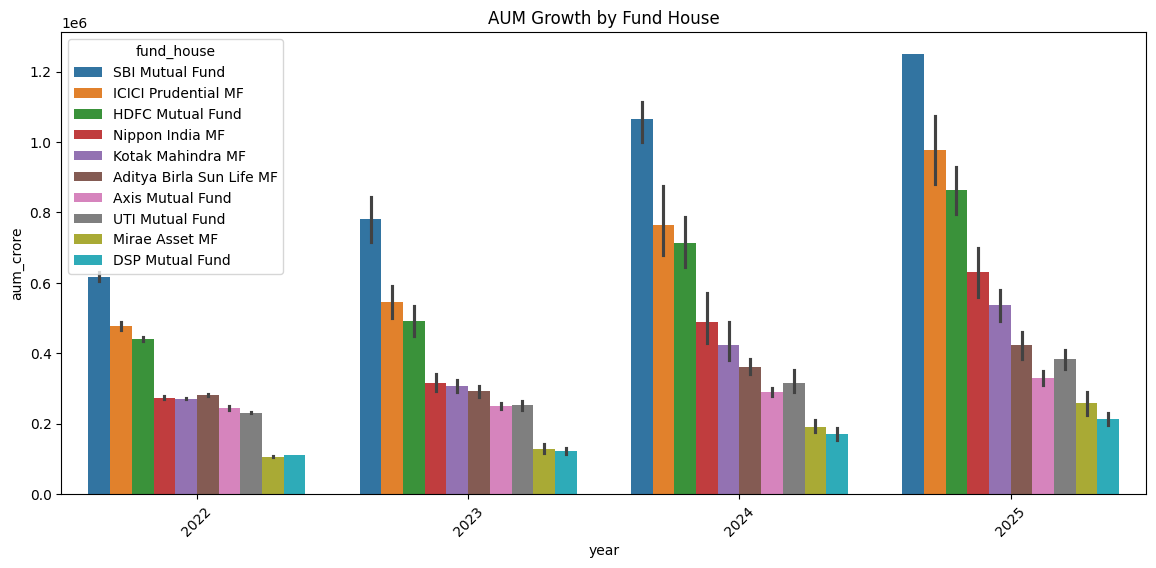

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

aum["date"] = pd.to_datetime(aum["date"])
aum["year"] = aum["date"].dt.year

plt.figure(figsize=(14,6))

sns.barplot(
    data=aum,
    x="year",
    y="aum_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House")
plt.xticks(rotation=45)
plt.show()

SBI Mutual Fund maintained the highest Assets Under Management (AUM) across the study period, highlighting its strong market presence and investor trust.

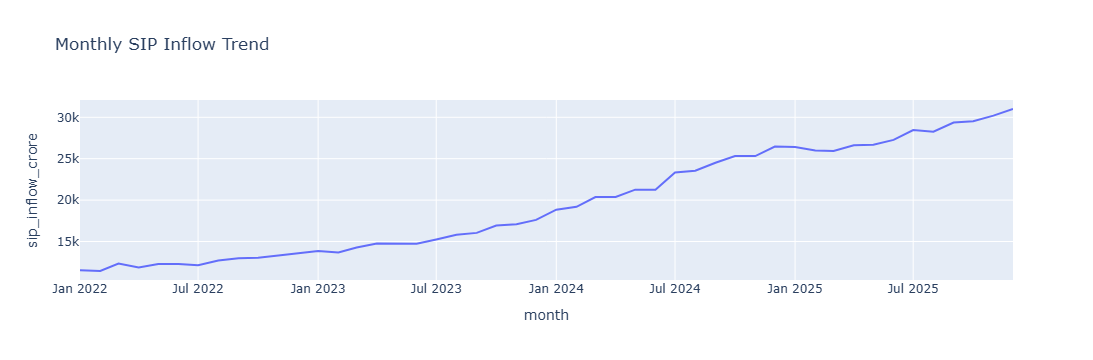

In [5]:
sip["month"] = pd.to_datetime(sip["month"])

import plotly.express as px

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflow Trend"
)

fig.show()

SIP inflows showed a steady upward trend from 2022 to 2025, indicating growing retail participation in mutual fund investments.

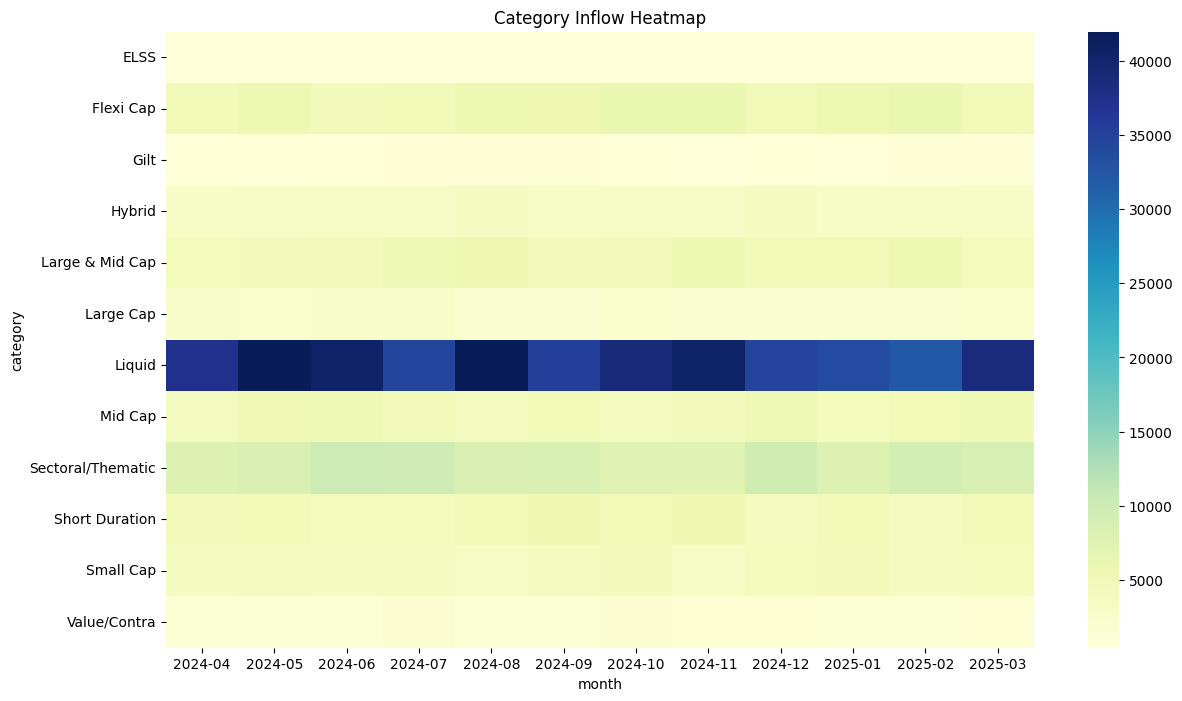

In [6]:
pivot = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

plt.figure(figsize=(14,8))

sns.heatmap(
    pivot,
    cmap="YlGnBu"
)

plt.title("Category Inflow Heatmap")
plt.show()

Equity-oriented categories consistently attracted higher inflows compared to debt and hybrid categories, reflecting investor preference for growth-oriented investments.

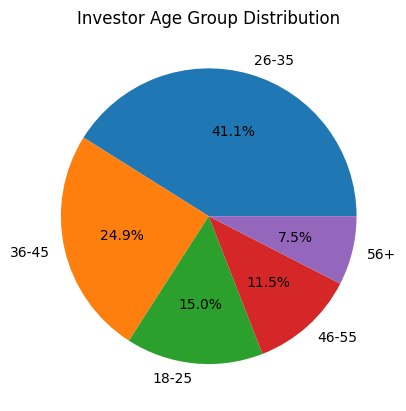

In [7]:
transactions["age_group"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Investor Age Group Distribution")
plt.ylabel("")
plt.show()

Investors in the 30–45 age group formed the largest segment of mutual fund participants.

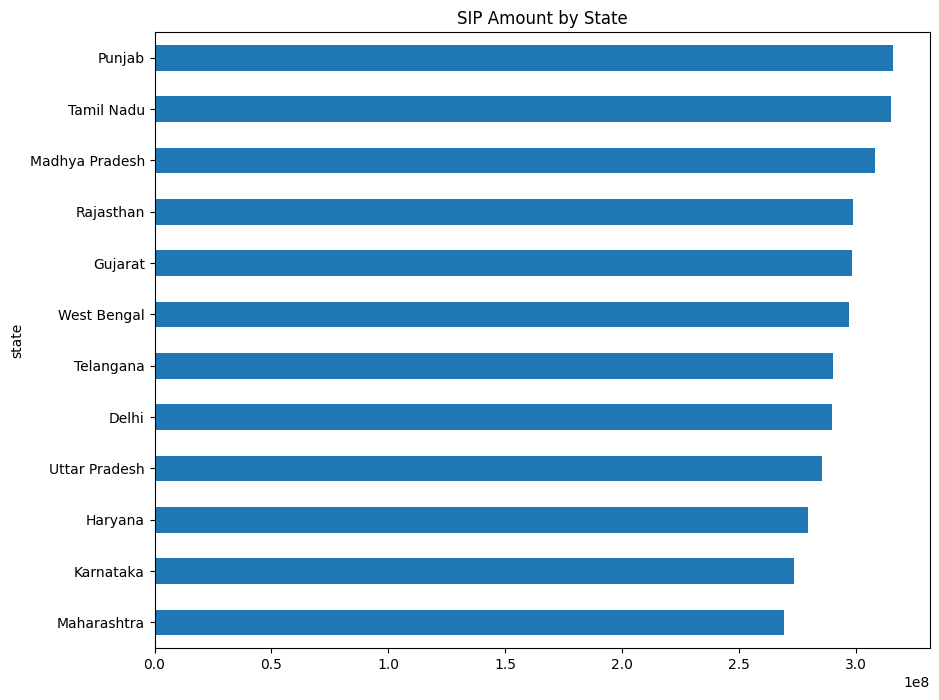

In [8]:
state_data = (
    transactions
    .groupby("state")["amount_inr"]
    .sum()
    .sort_values()
)

state_data.plot(
    kind="barh",
    figsize=(10,8)
)

plt.title("SIP Amount by State")
plt.show()

In [ ]:
Middle-aged investors contributed higher SIP amounts compared to younger and older age groups.

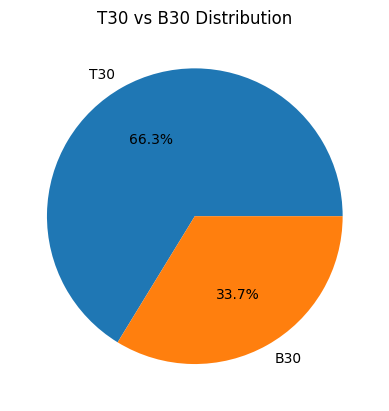

In [9]:
transactions["city_tier"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("T30 vs B30 Distribution")
plt.ylabel("")
plt.show()

T30 cities accounted for a larger share of investments than B30 cities, highlighting stronger penetration in metropolitan regions.

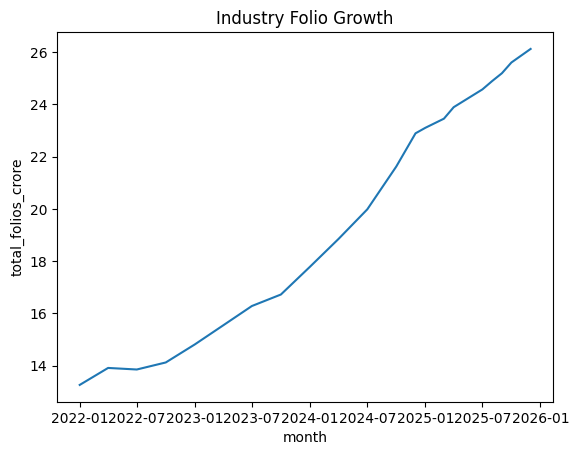

In [10]:
folios["month"] = pd.to_datetime(folios["month"])

sns.lineplot(
    data=folios,
    x="month",
    y="total_folios_crore"
)

plt.title("Industry Folio Growth")
plt.show()

Total mutual fund folios nearly doubled between 2022 and 2025, demonstrating rapid growth in investor participation.

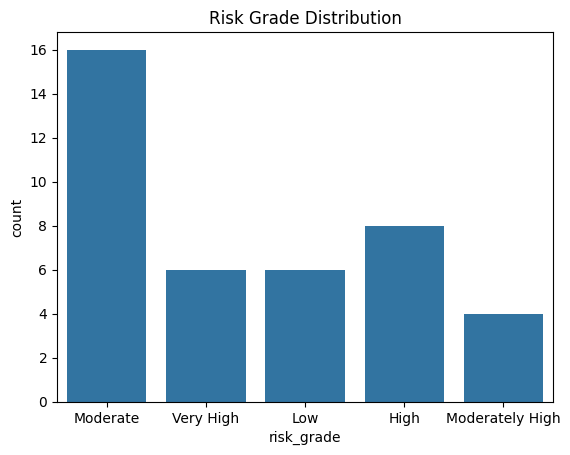

In [11]:
sns.countplot(
    data=performance,
    x="risk_grade"
)

plt.title("Risk Grade Distribution")
plt.show()

Most mutual fund schemes were categorized as High or Very High risk, reflecting the popularity of equity-oriented funds.

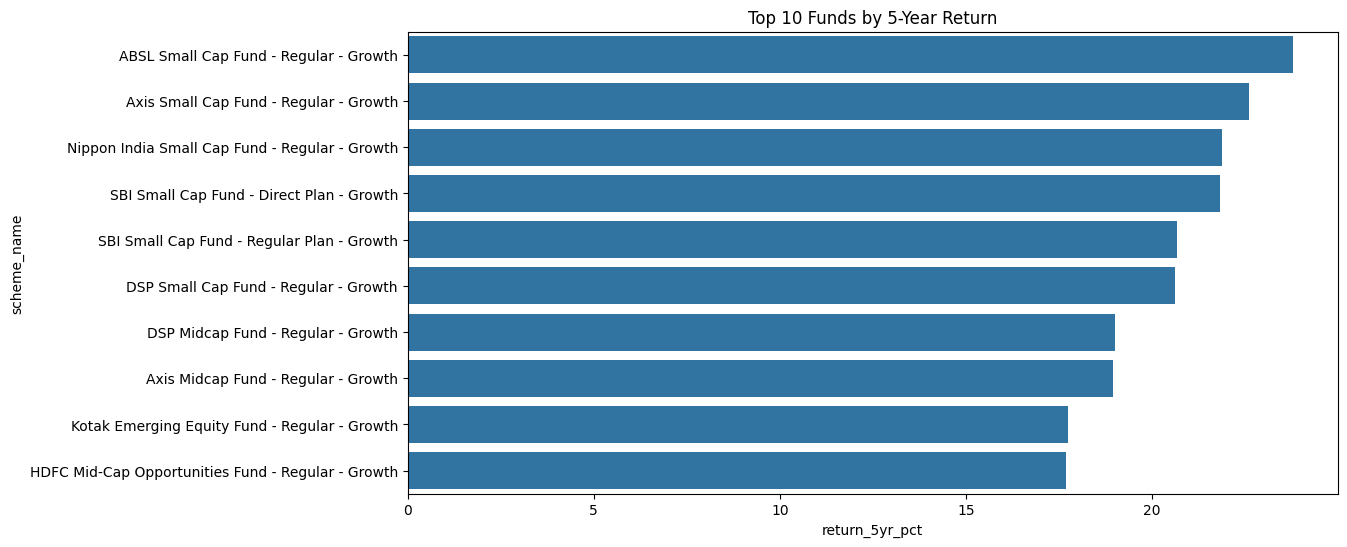

In [12]:
top10 = performance.sort_values(
    "return_5yr_pct",
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10,
    x="return_5yr_pct",
    y="scheme_name"
)

plt.title("Top 10 Funds by 5-Year Return")
plt.show()

The top-performing funds delivered significantly higher long-term returns, indicating strong fund management and investment strategy.

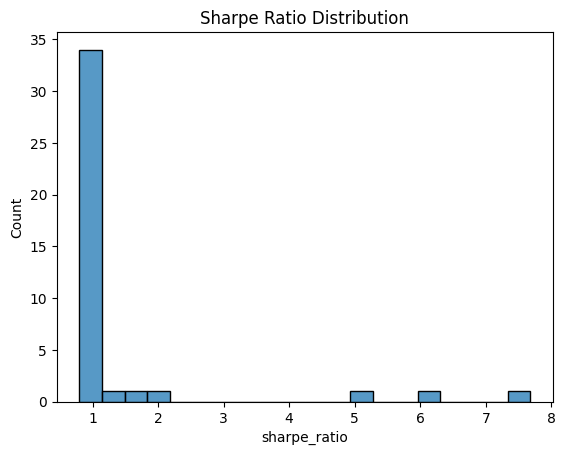

In [13]:
sns.histplot(
    performance["sharpe_ratio"],
    bins=20
)

plt.title("Sharpe Ratio Distribution")
plt.show()

Sharpe ratios varied considerably across schemes, showing differences in risk-adjusted performance.

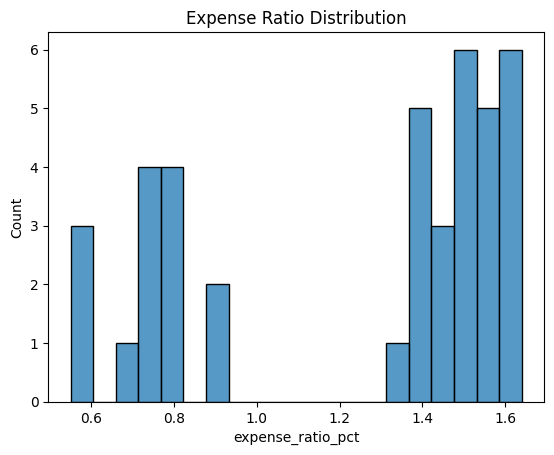

In [14]:
sns.histplot(
    performance["expense_ratio_pct"],
    bins=20
)

plt.title("Expense Ratio Distribution")
plt.show()

Most schemes maintained expense ratios below 2%, making them relatively cost-efficient for investors.

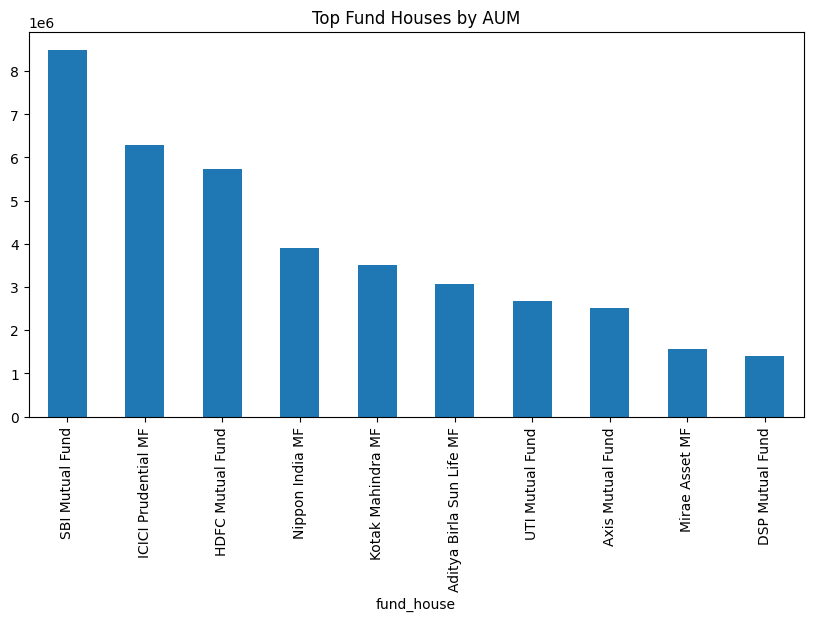

In [15]:
top_aum = (
    aum.groupby("fund_house")["aum_crore"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_aum.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top Fund Houses by AUM")
plt.show()

A small number of fund houses controlled a substantial share of the industry's total AUM.

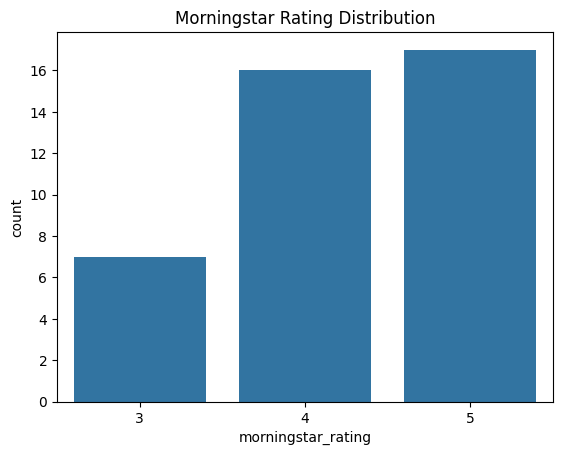

In [16]:
sns.countplot(
    data=performance,
    x="morningstar_rating"
)

plt.title("Morningstar Rating Distribution")
plt.show()

Most schemes were concentrated in the mid-to-high rating categories, indicating generally strong fund quality.